In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

## Dataloader

In [2]:
class CMAPSSLoaderDataset(Dataset):
    def __init__(self, data, sequence_length=30):
        self.data = data
        self.sequence_length = sequence_length
        self.sequences = []
        self.targets = []
        
        grouped = data.groupby('ID Engine') 
        for _, group in grouped:        
            values = group.drop(['ID Engine', 'Cycle', 'Remaining RUL'], axis=1).values
            rul_values = group['Remaining RUL'].values
            
            for i in range(len(values) - sequence_length + 1):
                self.sequences.append(values[i:i + sequence_length]) 
                self.targets.append(rul_values[i + sequence_length - 1])
    
    def __len__(self):
        return len(self.sequences)
    
    def __getitem__(self, idx):
        return (
            torch.tensor(self.sequences[idx], dtype=torch.float32),
            torch.tensor(self.targets[idx], dtype=torch.float32),
        )

## Transformer

In [3]:
class TransformerModel(nn.Module):
    def __init__(self, input_dim, d_model, nhead, num_layers, dim_feedforward, dropout):
        super(TransformerModel, self).__init__()
        self.input_embedding = nn.Linear(input_dim, d_model)
        self.positional_encoding = nn.Parameter(torch.zeros(1, 5000, d_model))
        self.transformer = nn.Transformer(
            d_model=d_model,
            nhead=nhead,
            num_encoder_layers=num_layers,
            num_decoder_layers=num_layers,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
        )
        self.fc_out = nn.Linear(d_model, 1)

    def forward(self, src):
        src_emb = self.input_embedding(src) + self.positional_encoding[:, :src.size(1), :]
        src_emb = src_emb.permute(1, 0, 2)
        transformer_out = self.transformer(src_emb, src_emb)
        output = self.fc_out(transformer_out[-1, :, :])
        return output.squeeze(-1)

In [4]:
train_1 = "../data/train_FD001.txt"
test_1 = "../data/test_FD001.txt"
rul_1 = "../data/RUL_FD001.txt"

## Tính toán RUL cho train

In [5]:
index_names = ['ID Engine', 'Cycle']
setting_names = ['Setting 1', 'Setting 2', 'Setting 3']
sensor_names = ['Sensor {}'.format(i) for i in range(1, 22)]
column_names = index_names + setting_names + sensor_names

train = pd.read_csv(train_1, sep=' ', header=None)
train.drop([26, 27], axis=1, inplace=True)
train.columns = column_names

train['Remaining RUL'] = ''
train.head()

,ID Engine,Cycle,Setting 1,Setting 2,Setting 3,Sensor 1,Sensor 2,Sensor 3,Sensor 4,Sensor 5,...,Sensor 13,Sensor 14,Sensor 15,Sensor 16,Sensor 17,Sensor 18,Sensor 19,Sensor 20,Sensor 21,Remaining RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,


In [6]:
max_cycle = train.groupby('ID Engine').count()

for idx in range(len(train)):
    train.loc[idx, 'Remaining RUL'] = max_cycle.loc[train.loc[idx, 'ID Engine'], 'Cycle']

train['Remaining RUL'] = train['Remaining RUL'] - train['Cycle']

In [7]:
train.head()

,ID Engine,Cycle,Setting 1,Setting 2,Setting 3,Sensor 1,Sensor 2,Sensor 3,Sensor 4,Sensor 5,...,Sensor 13,Sensor 14,Sensor 15,Sensor 16,Sensor 17,Sensor 18,Sensor 19,Sensor 20,Sensor 21,Remaining RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187


## Load RUL

In [8]:
rul = pd.read_csv(rul_1, sep=' ', header=None)
rul.drop(rul.columns[1], axis=1, inplace=True)
rul.columns = ['RUL']
rul.head()

,RUL
0,112
1,98
2,69
3,82
4,91


## Tính toán RUL cho test

In [10]:
test = pd.read_csv(test_1, sep=' ', header=None)
test.drop([26, 27], axis=1, inplace=True)
test.columns = column_names

test['Remaining RUL'] = ''
test.head()

,ID Engine,Cycle,Setting 1,Setting 2,Setting 3,Sensor 1,Sensor 2,Sensor 3,Sensor 4,Sensor 5,...,Sensor 13,Sensor 14,Sensor 15,Sensor 16,Sensor 17,Sensor 18,Sensor 19,Sensor 20,Sensor 21,Remaining RUL
0,1,1,0.0023,0.0003,100.0,518.67,643.02,1585.29,1398.21,14.62,...,2388.03,8125.55,8.4052,0.03,392,2388,100.0,38.86,23.3735,
1,1,2,-0.0027,-0.0003,100.0,518.67,641.71,1588.45,1395.42,14.62,...,2388.06,8139.62,8.3803,0.03,393,2388,100.0,39.02,23.3916,
2,1,3,0.0003,0.0001,100.0,518.67,642.46,1586.94,1401.34,14.62,...,2388.03,8130.10,8.4441,0.03,393,2388,100.0,39.08,23.4166,
3,1,4,0.0042,0.0000,100.0,518.67,642.44,1584.12,1406.42,14.62,...,2388.05,8132.90,8.3917,0.03,391,2388,100.0,39.00,23.3737,
4,1,5,0.0014,0.0000,100.0,518.67,642.51,1587.19,1401.92,14.62,...,2388.03,8129.54,8.4031,0.03,390,2388,100.0,38.99,23.4130,


In [12]:
max_cycle_test = test.groupby('ID Engine').count()
max_cycle_test['Cycle'].head()

ID Engine
1     31
2     49
3    126
4    106
5     98
Name: Cycle, dtype: int64

In [15]:
rul.head()

,RUL
0,112
1,98
2,69
3,82
4,91


In [16]:
for idx in range(len(test)):
    test.loc[idx, 'Remaining RUL'] = rul.loc[test.loc[idx, 'ID Engine'] - 1, 'RUL'] + max_cycle_test.loc[test.loc[idx, 'ID Engine'], 'Cycle']

test['Remaining RUL'] = test['Remaining RUL'] - test['Cycle']

In [17]:
test.head()

,ID Engine,Cycle,Setting 1,Setting 2,Setting 3,Sensor 1,Sensor 2,Sensor 3,Sensor 4,Sensor 5,...,Sensor 13,Sensor 14,Sensor 15,Sensor 16,Sensor 17,Sensor 18,Sensor 19,Sensor 20,Sensor 21,Remaining RUL
0,1,1,0.0023,0.0003,100.0,518.67,643.02,1585.29,1398.21,14.62,...,2388.03,8125.55,8.4052,0.03,392,2388,100.0,38.86,23.3735,142
1,1,2,-0.0027,-0.0003,100.0,518.67,641.71,1588.45,1395.42,14.62,...,2388.06,8139.62,8.3803,0.03,393,2388,100.0,39.02,23.3916,141
2,1,3,0.0003,0.0001,100.0,518.67,642.46,1586.94,1401.34,14.62,...,2388.03,8130.10,8.4441,0.03,393,2388,100.0,39.08,23.4166,140
3,1,4,0.0042,0.0000,100.0,518.67,642.44,1584.12,1406.42,14.62,...,2388.05,8132.90,8.3917,0.03,391,2388,100.0,39.00,23.3737,139
4,1,5,0.0014,0.0000,100.0,518.67,642.51,1587.19,1401.92,14.62,...,2388.03,8129.54,8.4031,0.03,390,2388,100.0,38.99,23.4130,138


In [18]:
test.groupby('ID Engine').max().min()

Cycle                 31
Setting 1         0.0029
Setting 2         0.0004
Setting 3          100.0
Sensor 1          518.67
Sensor 2          642.68
Sensor 3         1593.28
Sensor 4         1405.01
Sensor 5           14.62
Sensor 6           21.61
Sensor 7          553.78
Sensor 8         2388.05
Sensor 9         9045.99
Sensor 10            1.3
Sensor 11          47.39
Sensor 12         521.87
Sensor 13        2388.06
Sensor 14        8125.22
Sensor 15         8.4391
Sensor 16           0.03
Sensor 17            393
Sensor 18           2388
Sensor 19          100.0
Sensor 20          38.98
Sensor 21        23.3845
Remaining RUL        140
dtype: object

## Standard data (train and test)

In [19]:
scaled_columns = train.columns[2:]
scaler = MinMaxScaler()
train[scaled_columns] = scaler.fit_transform(train[scaled_columns])
test[scaled_columns] = scaler.fit_transform(test[scaled_columns])

In [20]:
train.head()

,ID Engine,Cycle,Setting 1,Setting 2,Setting 3,Sensor 1,Sensor 2,Sensor 3,Sensor 4,Sensor 5,...,Sensor 13,Sensor 14,Sensor 15,Sensor 16,Sensor 17,Sensor 18,Sensor 19,Sensor 20,Sensor 21,Remaining RUL
0,1,1,0.459770,0.166667,0.0,0.0,0.183735,0.406802,0.309757,0.0,...,0.205882,0.199608,0.363986,0.0,0.333333,0.0,0.0,0.713178,0.724662,0.529086
1,1,2,0.609195,0.250000,0.0,0.0,0.283133,0.453019,0.352633,0.0,...,0.279412,0.162813,0.411312,0.0,0.333333,0.0,0.0,0.666667,0.731014,0.526316
2,1,3,0.252874,0.750000,0.0,0.0,0.343373,0.369523,0.370527,0.0,...,0.220588,0.171793,0.357445,0.0,0.166667,0.0,0.0,0.627907,0.621375,0.523546
3,1,4,0.540230,0.500000,0.0,0.0,0.343373,0.256159,0.331195,0.0,...,0.294118,0.174889,0.166603,0.0,0.333333,0.0,0.0,0.573643,0.662386,0.520776
4,1,5,0.390805,0.333333,0.0,0.0,0.349398,0.257467,0.404625,0.0,...,0.235294,0.174734,0.402078,0.0,0.416667,0.0,0.0,0.589147,0.704502,0.518006


In [21]:
test.head()

,ID Engine,Cycle,Setting 1,Setting 2,Setting 3,Sensor 1,Sensor 2,Sensor 3,Sensor 4,Sensor 5,...,Sensor 13,Sensor 14,Sensor 15,Sensor 16,Sensor 17,Sensor 18,Sensor 19,Sensor 20,Sensor 21,Remaining RUL
0,1,1,0.65625,0.692308,0.0,0.0,0.596215,0.421968,0.282214,0.0,...,0.325581,0.152259,0.347076,0.0,0.375,0.0,0.0,0.500000,0.620099,0.405405
1,1,2,0.34375,0.230769,0.0,0.0,0.182965,0.504025,0.225240,0.0,...,0.395349,0.277907,0.227709,0.0,0.500,0.0,0.0,0.645455,0.645718,0.402402
2,1,3,0.53125,0.538462,0.0,0.0,0.419558,0.464814,0.346130,0.0,...,0.325581,0.192892,0.533557,0.0,0.500,0.0,0.0,0.700000,0.681104,0.399399
3,1,4,0.77500,0.461538,0.0,0.0,0.413249,0.391587,0.449867,0.0,...,0.372093,0.217896,0.282359,0.0,0.250,0.0,0.0,0.627273,0.620382,0.396396
4,1,5,0.60000,0.461538,0.0,0.0,0.435331,0.471306,0.357974,0.0,...,0.325581,0.187891,0.337009,0.0,0.125,0.0,0.0,0.618182,0.676008,0.393393


## Load data

In [ ]:
data_train = CMAPSSLoaderDataset(train, sequence_length=30)
data_test = CMAPSSLoaderDataset(test, sequence_length=30)

train_loader = DataLoader(data_train, batch_size=32, shuffle=True)
validation_loader = DataLoader(data_test, batch_size=32, shuffle=True)

In [23]:
data_train.__len__()

17731

In [24]:
# Input (sequence_length=30)
data_train.__getitem__(0)[0]

tensor([[0.4598, 0.1667, 0.0000, 0.0000, 0.1837, 0.4068, 0.3098, 0.0000, 1.0000,
         0.7262, 0.2424, 0.1098, 0.0000, 0.3690, 0.6333, 0.2059, 0.1996, 0.3640,
         0.0000, 0.3333, 0.0000, 0.0000, 0.7132, 0.7247],
        [0.6092, 0.2500, 0.0000, 0.0000, 0.2831, 0.4530, 0.3526, 0.0000, 1.0000,
         0.6280, 0.2121, 0.1002, 0.0000, 0.3810, 0.7655, 0.2794, 0.1628, 0.4113,
         0.0000, 0.3333, 0.0000, 0.0000, 0.6667, 0.7310],
        [0.2529, 0.7500, 0.0000, 0.0000, 0.3434, 0.3695, 0.3705, 0.0000, 1.0000,
         0.7101, 0.2727, 0.1400, 0.0000, 0.2500, 0.7953, 0.2206, 0.1718, 0.3574,
         0.0000, 0.1667, 0.0000, 0.0000, 0.6279, 0.6214],
        [0.5402, 0.5000, 0.0000, 0.0000, 0.3434, 0.2562, 0.3312, 0.0000, 1.0000,
         0.7407, 0.3182, 0.1245, 0.0000, 0.1667, 0.8891, 0.2941, 0.1749, 0.1666,
         0.0000, 0.3333, 0.0000, 0.0000, 0.5736, 0.6624],
        [0.3908, 0.3333, 0.0000, 0.0000, 0.3494, 0.2575, 0.4046, 0.0000, 1.0000,
         0.6683, 0.2424, 0.1500, 0.0000

In [25]:
# Output RUL
data_train.__getitem__(0)[1]

tensor(0.4488)

In [26]:
data_test.__len__()

10196

## Training model

In [27]:
def train(model, train_loader, validation_loader, epochs=50, verbose=False):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    input_dim = 24
    model = model.to(device)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

    for epoch in range(epochs):
        # Train
        model.train()
        train_loss = 0
        for batch in train_loader:
            seq, target = batch
            seq, target = seq.to(device), target.to(device)

            optimizer.zero_grad()
            output = model(seq)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        
        # Evaluate
        val_loss = 0
        model.eval()
        with torch.no_grad():
            for batch in validation_loader:
                seq, target = batch
                seq, target = seq.to(device), target.to(device)
                output = model(seq)
                loss = criterion(output, target)
                val_loss += loss.item()
        
        print(f"Epoch {epoch + 1}: Train Loss = {train_loss / len(train_loader)}, Val Loss = {val_loss / len(validation_loader)}")

In [28]:
model = TransformerModel(input_dim=24, d_model=64, nhead=4, num_layers=2, dim_feedforward=256, dropout=0.1)
train(model=model, train_loader=train_loader, validation_loader=validation_loader, epochs=50)

Epoch 1: Train Loss = 0.03500040123021012, Val Loss = 0.03701800107216933
Epoch 2: Train Loss = 0.016498617584573792, Val Loss = 0.03753172778455576
Epoch 3: Train Loss = 0.01438886251233451, Val Loss = 0.04039037965590625
Epoch 4: Train Loss = 0.013228779043456925, Val Loss = 0.046918035954024224
Epoch 5: Train Loss = 0.012203967655580994, Val Loss = 0.03947724040652783
Epoch 6: Train Loss = 0.010982315421842777, Val Loss = 0.040955414096525575
Epoch 7: Train Loss = 0.009936570065716903, Val Loss = 0.035460621539228174
Epoch 8: Train Loss = 0.009268278005188918, Val Loss = 0.040775525164870735
Epoch 9: Train Loss = 0.00860438882236931, Val Loss = 0.03718365181575392
Epoch 10: Train Loss = 0.008165034342154457, Val Loss = 0.0216558069355372
Epoch 11: Train Loss = 0.007935719616576895, Val Loss = 0.02234410150369832
Epoch 12: Train Loss = 0.00783481547160091, Val Loss = 0.02877119436917015
Epoch 13: Train Loss = 0.007580021676305379, Val Loss = 0.024005249479986644
Epoch 14: Train Loss 

## Evaluate model

## Predict on a batch

actual_predictions: [ 94.42789835  86.2236934   92.84411937  84.93711364  75.0709967
  90.86258945 105.05591393 108.96580005 109.37934035 112.57972747
 114.42415494 101.9522875  100.19618517 113.03342098 115.77028966
 100.45406482  83.83712819  94.46499491  96.59504008 119.80978549
 118.11850786 121.9801228   64.48982322  61.85908365  73.19492601
  62.26657021  51.51435857  53.89235425  58.44979268  69.22255233
  72.58630127  71.74381338]
actual_targets: [112.99999636 111.99999696 117.0000039  116.0000045  114.99999517
 113.99999577 112.99999636 111.99999696 110.99999756 109.99999815
 108.99999875 107.99999934 106.99999994 106.00000054 105.00000113
 104.00000173 103.00000232 102.00000292 101.00000352 100.00000411
  99.00000471  97.99999538 164.99999514 163.99999574 162.99999633
 161.99999693 160.99999753 159.99999812 158.99999872 157.99999931
 156.99999991 156.00000051]


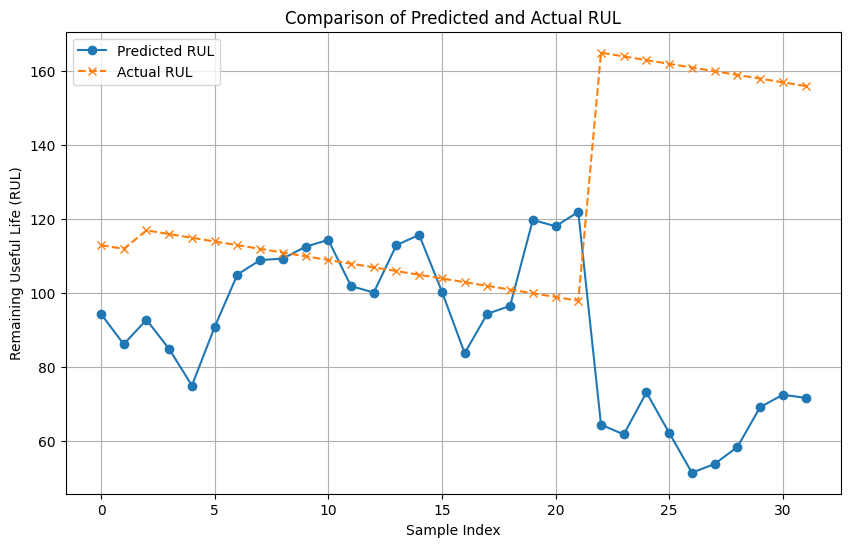

In [29]:
samples, targets = next(iter(validation_loader))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
samples, targets = samples.to(device), targets.to(device)

model.eval()
with torch.no_grad():
    predictions = model(samples)

# Đưa kết quả về CPU để xử lý
samples = samples.cpu()
targets = targets.cpu()
predictions = predictions.cpu()

# Đảo chuẩn hóa dữ liệu
rul_min = scaler.data_min_[-1]
rul_max = scaler.data_max_[-1]

# Đưa predictions và targets về dạng thực tế
actual_predictions = predictions.numpy() * (rul_max - rul_min) + rul_min
actual_targets = targets.numpy() * (rul_max - rul_min) + rul_min
print(f'actual_predictions: {actual_predictions}')
print(f'actual_targets: {actual_targets}')

# Vẽ biểu đồ so sánh dự đoán và giá trị thực tế
plt.figure(figsize=(10, 6))
plt.plot(range(len(actual_predictions)), actual_predictions, label="Predicted RUL", marker='o', linestyle='-')
plt.plot(range(len(actual_targets)), actual_targets, label="Actual RUL", marker='x', linestyle='--')
plt.title("Comparison of Predicted and Actual RUL")
plt.xlabel("Sample Index")
plt.ylabel("Remaining Useful Life (RUL)")
plt.legend()
plt.grid(True)
plt.show()

## Predict on a sample